<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/process_cost_estimation_and_economics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From process simulation to CAPEX, OPEX, and economic screening with NeqSim

This notebook connects a rigorous NeqSim gas-process simulation to mechanical design, equipment-factored capital cost, annual operating cost, and simple project-economic indicators. It is designed for concept selection and early study work: the calculations are transparent and reproducible, but they are **screening estimates—not vendor quotations or project sanctions**.

The worked case is a compact gas compression train: inlet separation, compression, aftercooling, and export pressure control.

In [1]:
# Install NeqSim from PyPI when the runtime does not already provide it.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])

import importlib.metadata
import json
import math

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim

NEQSIM_VERSION = importlib.metadata.version("neqsim")
JAVA_VERSION = str(jpype.java.lang.System.getProperty("java.version"))
print(f"NeqSim Python package: {NEQSIM_VERSION}")
print(f"Python: {sys.version.split()[0]}; Java: {JAVA_VERSION}")

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.3f}".format

NeqSim Python package: 3.16.0
Python: 3.12.13; Java: 17.0.19


## Learning objectives and workflow

After completing the notebook, you should be able to:

1. build and run a reproducible gas-process model with current NeqSim Python/JVM APIs;
2. connect simulated duties and equipment to NeqSim mechanical-design and cost objects;
3. distinguish purchased equipment cost (PEC), bare-module cost (BMC), total-module cost (TMC), grass-roots cost (GRC), and total project cost;
4. calculate annual utility and operating costs without mixing physical quantities with currency rows;
5. evaluate location, material, complexity, throughput, and CEPCI sensitivities; and
6. apply reconciliation checks before using results in an engineering decision.

The governing principle is that **the process model defines the physical sizing basis; the estimate model then maps that basis to study costs**.

In [2]:
STUDY_BASIS = {
    "Thermodynamic model": "SRK equation of state, classic mixing rule",
    "Feed rate": "10,000 kg/h",
    "Feed conditions": "25 degC and 50 bara",
    "Compressor discharge": "100 bara",
    "Compressor isentropic efficiency": "0.75",
    "Aftercooler outlet": "35 degC",
    "Export pressure": "95 bara",
    "Operating time": "8,000 h/year",
    "Cost currency": "2025-basis USD unless otherwise stated",
    "Estimate purpose": "concept/study screening",
}
display(pd.Series(STUDY_BASIS, name="Value").to_frame())

def java_map_to_dict(java_map):
    """Convert a Java Map<String, Number> to a normal Python dict of floats."""
    return {str(entry.getKey()): float(entry.getValue()) for entry in java_map.entrySet()}

,Value
Thermodynamic model,"SRK equation of state, classic mixing rule"
Feed rate,"10,000 kg/h"
Feed conditions,25 degC and 50 bara
Compressor discharge,100 bara
Compressor isentropic efficiency,0.75
Aftercooler outlet,35 degC
Export pressure,95 bara
Operating time,"8,000 h/year"
Cost currency,2025-basis USD unless otherwise stated
Estimate purpose,concept/study screening


## Process and fluid design basis

The synthetic gas is intentionally small enough to understand but rich enough to exercise phase equilibrium and realistic compression work. Mole fractions sum to one. The flow rate and pressure ratio are illustrative and are not tied to a real asset.

The SRK equation of state is a common first model for hydrocarbon-gas processing. A real study should justify the thermodynamic model against fluid composition, water content, contaminants, pressure range, and available laboratory data. Cost estimates inherit every uncertainty in that process basis.

In [3]:
FEED_COMPOSITION = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.84,
    "ethane": 0.08,
    "propane": 0.04,
    "n-butane": 0.01,
}

composition_table = (
    pd.Series(FEED_COMPOSITION, name="mole fraction")
    .rename_axis("component")
    .to_frame()
)
composition_table["mol%"] = 100.0 * composition_table["mole fraction"]
display(composition_table)
print(f"Composition sum: {sum(FEED_COMPOSITION.values()):.6f}")
assert abs(sum(FEED_COMPOSITION.values()) - 1.0) < 1e-12

Composition sum: 1.000000


,mole fraction,mol%
component,,
nitrogen,0.010,1.000
CO2,0.020,2.000
methane,0.840,84.000
ethane,0.080,8.000
propane,0.040,4.000
n-butane,0.010,1.000


## Physical model and cost hierarchy

The steady-state process solves phase equilibrium and equipment energy balances. NeqSim then initializes mechanical-design objects and applies its equipment cost correlations. The principal estimate layers are

$$\mathrm{PEC} \rightarrow \mathrm{BMC} \rightarrow \mathrm{TMC} \rightarrow \mathrm{GRC}.$$

PEC is the purchased equipment cost. BMC adds installation-related material and labor factors. TMC adds engineering and contingency factors used by the correlation framework. GRC adds site development and auxiliary facilities. The report also exposes a project-cost stack above GRC. These are different scopes; they must not be added to one another as if they were independent line items.

In [4]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

def build_process(flow_kg_per_h=10_000.0):
    fluid = SystemSrkEos(298.15, 50.0)
    for component, fraction in FEED_COMPOSITION.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")

    process = ProcessSystem()
    process.setName(f"Gas compression screening - {flow_kg_per_h:,.0f} kg/h")

    feed = Stream("Feed", fluid)
    feed.setFlowRate(float(flow_kg_per_h), "kg/hr")
    feed.setTemperature(25.0, "C")
    feed.setPressure(50.0, "bara")

    separator = Separator("Inlet separator", feed)
    compressor = Compressor("Export compressor", separator.getGasOutStream())
    compressor.setOutletPressure(100.0)
    compressor.setIsentropicEfficiency(0.75)
    cooler = Cooler("Aftercooler", compressor.getOutletStream())
    cooler.setOutTemperature(35.0, "C")
    valve = ThrottlingValve("Export control valve", cooler.getOutletStream())
    valve.setOutletPressure(95.0)

    for unit in [feed, separator, compressor, cooler, valve]:
        process.add(unit)

    return {
        "process": process, "feed": feed, "separator": separator,
        "compressor": compressor, "cooler": cooler, "valve": valve,
    }

## Run the steady-state base case

The first calculation closes the physical model before any cost is calculated. This separation is useful in practice: if pressure, temperature, phase split, or duty is wrong, a detailed cost table only gives false precision.

The reported mass-balance error checks the inlet separator because its gas outlet feeds the compression train while any liquid leaves the modeled export path.

In [5]:
base = build_process()
base["process"].run()

feed_flow = float(base["feed"].getFlowRate("kg/hr"))
gas_flow = float(base["separator"].getGasOutStream().getFlowRate("kg/hr"))
liquid_flow = float(base["separator"].getLiquidOutStream().getFlowRate("kg/hr"))
export_flow = float(base["valve"].getOutletStream().getFlowRate("kg/hr"))
compressor_power_kw = float(base["compressor"].getPower("kW"))
compressor_outlet_c = float(base["compressor"].getOutletStream().getTemperature("C"))
export_pressure_bara = float(base["valve"].getOutletStream().getPressure("bara"))
mass_balance_error = abs(feed_flow - gas_flow - liquid_flow) / feed_flow

process_results = pd.Series({
    "Feed flow [kg/h]": feed_flow,
    "Separator gas [kg/h]": gas_flow,
    "Separator liquid [kg/h]": liquid_flow,
    "Export gas [kg/h]": export_flow,
    "Compressor power [kW]": compressor_power_kw,
    "Compressor outlet [degC]": compressor_outlet_c,
    "Export pressure [bara]": export_pressure_bara,
    "Separator mass-balance error [-]": mass_balance_error,
}, name="Base case")
display(process_results.to_frame())

,Base case
Feed flow [kg/h],"10,000.000"
Separator gas [kg/h],"10,000.000"
Separator liquid [kg/h],0.000
Export gas [kg/h],"10,000.000"
Compressor power [kW],316.417
Compressor outlet [degC],87.360
Export pressure [bara],95.000
Separator mass-balance error [-],0.000


## Mechanical design as the cost bridge

Cost correlations need equipment size, pressure, duty, power, material, and weight—not merely a flowsheet tag. `runMechanicalDesignAndCostEstimation()` coordinates NeqSim's system mechanical design and process cost estimate.

The default messages printed by some mechanical-design objects indicate that generic study standards are being used. For an actual project, configure the governing design code, project technical requirements, corrosion allowance, materials, design pressure/temperature margins, and vendor constraints before relying on dimensions or weights.

In [6]:
base["process"].runMechanicalDesignAndCostEstimation()
mechanical = base["process"].getSystemMechanicalDesign()
cost = base["process"].getCostEstimate()

mechanical_summary = pd.Series({
    "Designed equipment count": int(mechanical.getEquipmentList().size()),
    "Total estimated equipment weight [kg]": float(mechanical.getTotalWeight()),
    "Total required power [kW]": float(mechanical.getTotalPowerRequired()),
    "Separator design pressure [bara]": float(
        base["process"].getEquipmentMechanicalDesign("Inlet separator").getMaxDesignPressure()
    ),
}, name="Mechanical design")
display(mechanical_summary.to_frame())

,Mechanical design
Designed equipment count,5.000
Total estimated equipment weight [kg],"1,299.254"
Total required power [kW],316.417
Separator design pressure [bara],110.000


## Read the CAPEX scopes without double counting

The cost hierarchy should be monotonic for this study estimate:

$$\mathrm{PEC} < \mathrm{BMC} < \mathrm{TMC} < \mathrm{GRC} < \mathrm{Total\ Project\ Cost}.$$

This relationship is a scope check, not a universal economic law. The authoritative report metadata states the estimate class, cost year, location basis, and expected accuracy range. Keep that basis beside every number exported to a decision document.

In [7]:
cost.calculateAllCosts()
capex = pd.Series({
    "Purchased equipment cost (PEC)": float(cost.getTotalPurchasedEquipmentCost()),
    "Bare module cost (BMC)": float(cost.getTotalBareModuleCost()),
    "Total module cost (TMC)": float(cost.getTotalModuleCost()),
    "Grass-roots cost (GRC)": float(cost.getTotalGrassRootsCost()),
    "Total project cost": float(cost.getTotalProjectCost()),
}, name="USD")
display(capex.to_frame().style.format("${:,.0f}"))

assert np.all(np.isfinite(capex.values))
assert np.all(np.diff(capex.values) > 0), "Expected increasing cost scopes"

,USD
Purchased equipment cost (PEC),"$266,870"
Bare module cost (BMC),"$1,098,839"
Total module cost (TMC),"$1,373,549"
Grass-roots cost (GRC),"$1,579,581"
Total project cost,"$1,974,477"


## Equipment and discipline views

Two breakdowns answer different questions. Equipment-type PEC shows which purchased items dominate. The discipline view is a factored allocation used for early screening of piping, electrical/instrumentation, civil/structural, and other installation scope.

Only rows from the same scope should be summed. In particular, do not add the discipline allocation to BMC or GRC; it explains part of an installed-cost picture rather than creating a second independent project total.

,Located PEC [USD]
Streams,$0
Vessels,"$2,826"
Compressors,"$210,017"
Heat Exchangers,"$1,056"
Valves,"$52,972"


,Factored cost [USD]
Process Equipment,"$266,870"
Piping & Valves,"$915,699"
Electrical & Instrumentation,"$549,420"
Civil & Structural,"$366,280"
"Other (HVAC, Paint, Insulation)","$732,559"


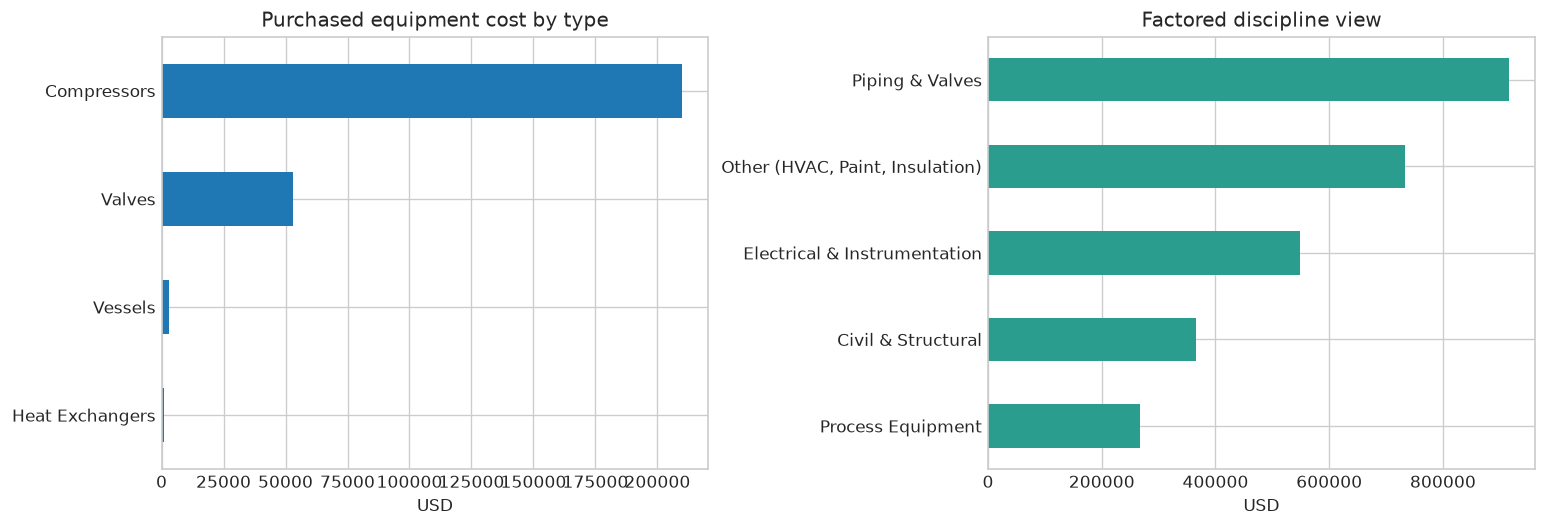

In [8]:
equipment_costs = pd.Series(java_map_to_dict(cost.getCostByEquipmentType()), name="Located PEC [USD]")
discipline_costs = pd.Series(java_map_to_dict(cost.getCostByDiscipline()), name="Factored cost [USD]")
display(equipment_costs.to_frame().style.format("${:,.0f}"))
display(discipline_costs.to_frame().style.format("${:,.0f}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
equipment_costs[equipment_costs > 0].sort_values().plot.barh(ax=axes[0], color="#1f77b4")
discipline_costs.sort_values().plot.barh(ax=axes[1], color="#2a9d8f")
axes[0].set_title("Purchased equipment cost by type")
axes[1].set_title("Factored discipline view")
for ax in axes:
    ax.set_xlabel("USD")
fig.tight_layout()
plt.show()

## Audit the machine-readable estimate basis

NeqSim's JSON output is useful for automated studies and agentic workflows because it keeps totals, additive lines, summary lines, non-cost quantities, and estimate-basis metadata separate.

For this example the default estimate is a study-level, equipment-factored estimate. Its accuracy range is much wider than the numerical precision displayed by Python. Good reporting rounds appropriately and retains the basis metadata.

In [9]:
cost_json = json.loads(str(cost.toJson()))
estimate_basis = pd.Series(cost_json["estimateBasis"], name="Estimate basis")
project_stack = pd.Series(cost_json["projectCostBreakdown_USD"], name="USD")
display(estimate_basis.to_frame())
display(project_stack.to_frame().style.format({"USD": "${:,.0f}"}))

required_json_sections = {
    "costSummary", "factors", "estimateBasis", "projectCostBreakdown_USD",
    "detailedEstimateResult", "costByEquipmentType_USD", "equipment",
}
assert required_json_sections.issubset(cost_json)

,Estimate basis
estimateClass,CLASS_4
estimateClassNumber,4
maturity,Study
estimatingMethod,equipment-factored
dataSource,correlation
accuracyLowFraction,-0.300
accuracyHighFraction,0.500
currencyCode,USD
costYear,2025
locationFactor,1.000


,USD
directInstalledCost,"$1,373,549"
indirectCost,"$206,032"
projectContingency,"$157,958"
ownerCost,"$236,937"
totalProjectCost,"$1,974,477"


## Annual operating-cost screening

The default OPEX method estimates electricity for rotating equipment, utilities for thermal equipment, maintenance, labor, supervision, supplies, laboratory support, and overhead. For the compressor contribution,

$$C_{\mathrm{electricity}} = P\,t_{\mathrm{op}}\,c_{\mathrm{electricity}},$$

where $P$ is shaft power, $t_{\mathrm{op}}$ is annual operating time, and $c_{\mathrm{electricity}}$ is the electricity price. Replace all default prices and staffing assumptions with project-specific values before comparing concepts.

In [10]:
OPERATING_HOURS = 8_000
annual_opex = float(cost.calculateOperatingCost(OPERATING_HOURS))
opex_breakdown = pd.Series(java_map_to_dict(cost.getOperatingCostBreakdown()), name="Annual USD")
display(opex_breakdown.to_frame().style.format("${:,.0f}"))
print(f"Total annual OPEX: ${annual_opex:,.0f}/year")

opex_reconciliation_error = abs(opex_breakdown.sum() - annual_opex) / annual_opex
assert opex_reconciliation_error < 1e-12

Total annual OPEX: $1,891,507/year


,Annual USD
Electricity,"$202,507"
Steam,$0
Cooling Water,"$14,047"
Maintenance,"$54,942"
Operating Labor,"$800,000"
Supervision,"$144,000"
Operating Supplies,"$6,593"
Laboratory,"$120,000"
Overhead,"$549,418"


## Simple economic indicators

The built-in financial functions treat the supplied annual revenue as a constant annual benefit and subtract modeled OPEX. With annual net cash flow $F$, discount rate $r$, project life $N$, and initial grass-roots cost $I_0$,

$$\mathrm{NPV}=-I_0+\sum_{n=1}^{N}\frac{F}{(1+r)^n}.$$

This is deliberately simple. A field-development model normally includes production decline, ramp-up, taxes, royalties, working capital, abandonment, depreciation, inflation, price uncertainty, and staged investment.

In [11]:
ANNUAL_REVENUE_USD = 3_000_000.0
DISCOUNT_RATE = 0.08
PROJECT_LIFE_YEARS = 20

economic_metrics = pd.Series({
    "Annual revenue [USD/year]": ANNUAL_REVENUE_USD,
    "Annual OPEX [USD/year]": annual_opex,
    "Annual net cash flow [USD/year]": ANNUAL_REVENUE_USD - annual_opex,
    "Simple payback [years]": float(cost.calculatePaybackPeriod(ANNUAL_REVENUE_USD)),
    "Simple ROI [%]": float(cost.calculateROI(ANNUAL_REVENUE_USD)),
    "NPV [USD]": float(cost.calculateNPV(ANNUAL_REVENUE_USD, DISCOUNT_RATE, PROJECT_LIFE_YEARS)),
}, name="Screening result")
display(economic_metrics.to_frame())

,Screening result
Annual revenue [USD/year],"3,000,000.000"
Annual OPEX [USD/year],"1,891,507.019"
Annual net cash flow [USD/year],"1,108,492.981"
Simple payback [years],1.425
Simple ROI [%],70.176
NPV [USD],"9,303,766.276"


## Location, material, and complexity scenarios

Early cost uncertainty is often driven more by scope and basis than by thermodynamic precision. The next cases isolate three common drivers:

* a North Sea location factor relative to the US Gulf Coast basis;
* SS316 material relative to carbon steel; and
* a complexity factor for a more difficult project configuration.

The cases rebuild the process independently so settings do not leak from one estimate into another.

,location factor,PEC [USD],GRC [USD],project cost [USD]
case,,,,
US Gulf / carbon steel,1.00,"$266,870","$1,579,581","$1,974,477"
North Sea / carbon steel,1.35,"$360,275","$2,132,435","$2,665,543"
North Sea / SS316,1.35,"$600,680","$5,671,100","$7,088,875"
North Sea / SS316 / complex,1.35,"$600,680","$6,521,765","$8,152,206"


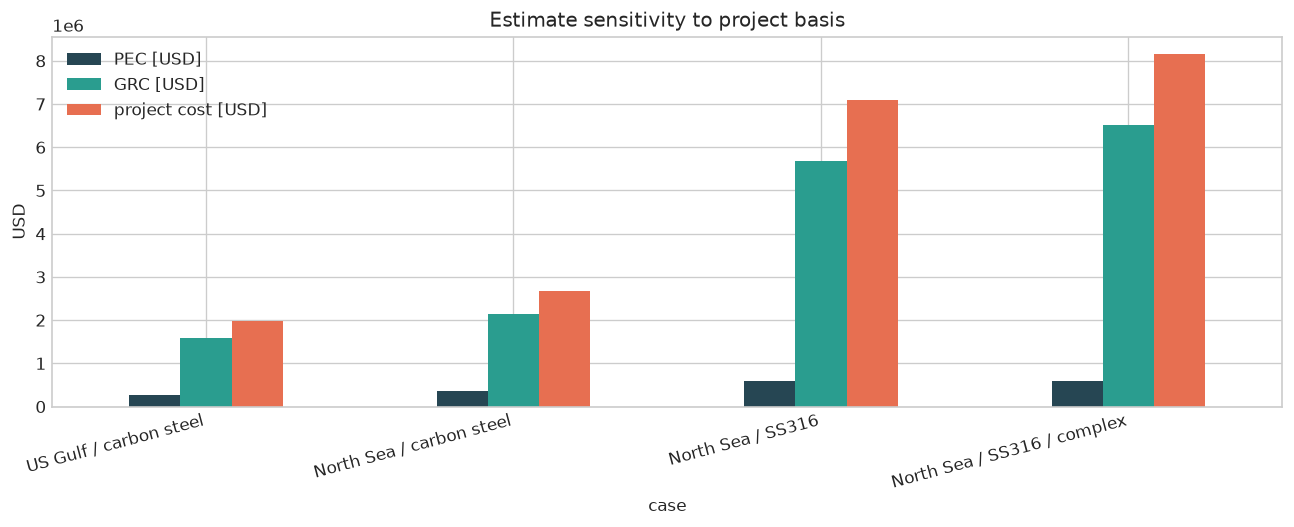

In [12]:
def estimate_case(name, location="US Gulf Coast", material="Carbon Steel", complexity=1.0,
                  flow_kg_per_h=10_000.0, cepci=None):
    case = build_process(flow_kg_per_h)
    case["process"].run()
    case_cost = case["process"].getCostEstimate()
    case_cost.setLocationByRegion(location)
    case_cost.setMaterial(material)
    case_cost.setComplexityFactor(float(complexity))
    if cepci is not None:
        case_cost.setCepci(float(cepci))
    case_cost.calculateAllCosts()
    return {
        "case": name,
        "location factor": float(case_cost.getLocationFactor()),
        "PEC [USD]": float(case_cost.getTotalPurchasedEquipmentCost()),
        "GRC [USD]": float(case_cost.getTotalGrassRootsCost()),
        "project cost [USD]": float(case_cost.getTotalProjectCost()),
    }

scenario_results = pd.DataFrame([
    estimate_case("US Gulf / carbon steel"),
    estimate_case("North Sea / carbon steel", location="North Sea"),
    estimate_case("North Sea / SS316", location="North Sea", material="SS316"),
    estimate_case("North Sea / SS316 / complex", location="North Sea", material="SS316", complexity=1.15),
]).set_index("case")
display(scenario_results.style.format({
    "location factor": "{:.2f}", "PEC [USD]": "${:,.0f}",
    "GRC [USD]": "${:,.0f}", "project cost [USD]": "${:,.0f}",
}))

scenario_results[["PEC [USD]", "GRC [USD]", "project cost [USD]"]].plot.bar(
    figsize=(11, 4.5), color=["#264653", "#2a9d8f", "#e76f51"]
)
plt.ylabel("USD")
plt.title("Estimate sensitivity to project basis")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Throughput sensitivity and economy of scale

Equipment-factored costs generally grow sublinearly with capacity over a valid correlation range. A useful diagnostic is the apparent scale exponent

$$n=\frac{\ln(C_2/C_1)}{\ln(Q_2/Q_1)},$$

where $C$ is cost and $Q$ is capacity. This exponent is an observed result of the selected process and correlations, not a universal design constant. Large capacity changes can require parallel trains, different equipment technology, or new pressure levels.

Apparent GRC scale exponent from 5,000 to 20,000 kg/h: 0.642


,PEC [USD],GRC [USD],project cost [USD]
flow [kg/h],,,
5000.000000,"$173,664","$1,027,900","$1,284,875"
10000.000000,"$266,870","$1,579,581","$1,974,477"
15000.000000,"$348,666","$2,063,722","$2,579,652"
20000.000000,"$422,936","$2,503,320","$3,129,150"


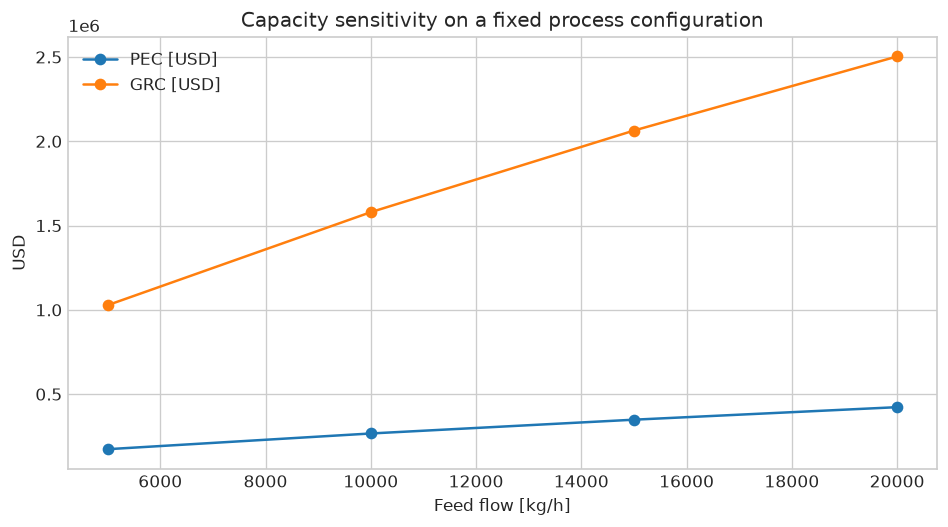

In [13]:
throughputs = np.array([5_000.0, 10_000.0, 15_000.0, 20_000.0])
throughput_results = pd.DataFrame([
    {"flow [kg/h]": flow, **estimate_case(f"{flow:,.0f} kg/h", flow_kg_per_h=flow)}
    for flow in throughputs
]).set_index("flow [kg/h]")

scale_exponent = math.log(
    throughput_results["GRC [USD]"].iloc[-1] / throughput_results["GRC [USD]"].iloc[0]
) / math.log(throughputs[-1] / throughputs[0])
display(throughput_results[["PEC [USD]", "GRC [USD]", "project cost [USD]"]].style.format("${:,.0f}"))
print(f"Apparent GRC scale exponent from 5,000 to 20,000 kg/h: {scale_exponent:.3f}")

throughput_results[["PEC [USD]", "GRC [USD]"]].plot(marker="o", figsize=(8, 4.5))
plt.xlabel("Feed flow [kg/h]")
plt.ylabel("USD")
plt.title("Capacity sensitivity on a fixed process configuration")
plt.tight_layout()
plt.show()

## CEPCI cost-index sensitivity

Historical equipment correlations are escalated with the Chemical Engineering Plant Cost Index (CEPCI):

$$C_{\mathrm{current}}=C_{\mathrm{base}}\frac{I_{\mathrm{current}}}{I_{\mathrm{base}}}.$$

The example sweeps the index to demonstrate this mechanism. The chosen values are sensitivity inputs, not a claim about the latest published CEPCI. A report must state the actual index, date, source, and currency basis used.

,PEC [USD],GRC [USD]
CEPCI,,
600.000000,"$190,923","$1,130,058"
700.000000,"$222,568","$1,317,359"
800.000000,"$254,213","$1,504,661"
900.000000,"$285,857","$1,691,962"


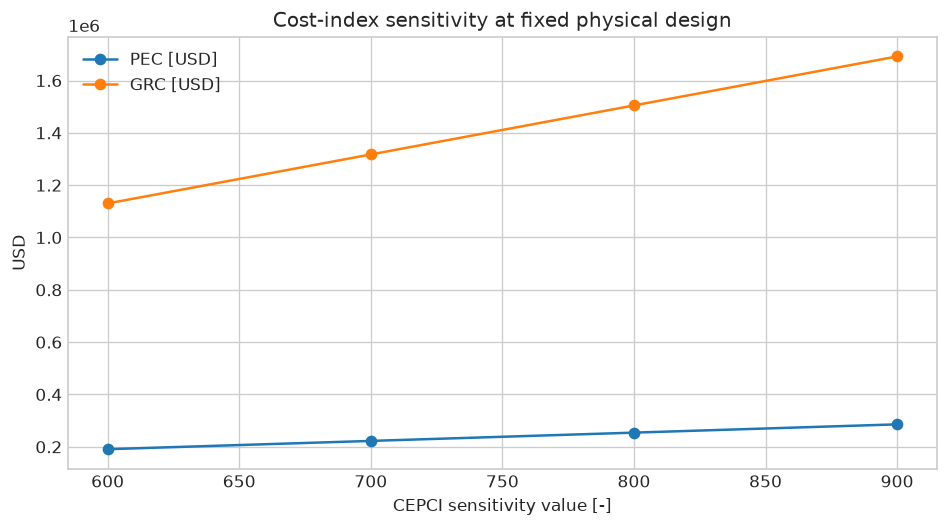

In [14]:
cepci_values = [600.0, 700.0, 800.0, 900.0]
cepci_results = pd.DataFrame([
    {"CEPCI": index, **estimate_case(f"CEPCI {index:.0f}", cepci=index)}
    for index in cepci_values
]).set_index("CEPCI")
display(cepci_results[["PEC [USD]", "GRC [USD]"]].style.format("${:,.0f}"))

cepci_results[["PEC [USD]", "GRC [USD]"]].plot(marker="o", figsize=(8, 4.5))
plt.xlabel("CEPCI sensitivity value [-]")
plt.ylabel("USD")
plt.title("Cost-index sensitivity at fixed physical design")
plt.tight_layout()
plt.show()

## Validation gate

An automated notebook should fail loudly when a physical or reporting invariant is violated. The checks below cover composition closure, separator mass balance, process specifications, finite duties, cost-scope order, breakdown reconciliation, scenario trends, and JSON structure.

Passing these checks demonstrates internal consistency for this example. It does not validate the cost correlations for a particular project, guarantee a vendor price, or replace independent estimating review.

In [15]:
checks = {
    "Composition closes": abs(sum(FEED_COMPOSITION.values()) - 1.0) < 1e-12,
    "Separator mass balance closes": mass_balance_error < 1e-10,
    "Compressor power is finite and positive": np.isfinite(compressor_power_kw) and compressor_power_kw > 0,
    "Export pressure meets specification": abs(export_pressure_bara - 95.0) < 1e-8,
    "Mechanical weight is positive": float(mechanical.getTotalWeight()) > 0,
    "CAPEX scopes increase": bool(np.all(np.diff(capex.values) > 0)),
    "Equipment PEC reconciles": abs(equipment_costs.sum() - capex.iloc[0]) / capex.iloc[0] < 1e-10,
    "OPEX rows reconcile": opex_reconciliation_error < 1e-12,
    "North Sea location increases GRC": scenario_results["GRC [USD]"].iloc[1] > scenario_results["GRC [USD]"].iloc[0],
    "SS316 increases PEC": scenario_results["PEC [USD]"].iloc[2] > scenario_results["PEC [USD]"].iloc[1],
    "Capacity trend is monotonic": throughput_results["GRC [USD]"].is_monotonic_increasing,
    "CEPCI trend is monotonic": cepci_results["PEC [USD]"].is_monotonic_increasing,
    "NPV is finite": np.isfinite(economic_metrics["NPV [USD]"]),
    "Required JSON sections exist": required_json_sections.issubset(cost_json),
}
validation_table = pd.Series(checks, name="Passed").rename_axis("Check").to_frame()
display(validation_table)
assert validation_table["Passed"].all(), validation_table[~validation_table["Passed"]]

,Passed
Check,
Composition closes,True
Separator mass balance closes,True
Compressor power is finite and positive,True
Export pressure meets specification,True
Mechanical weight is positive,True
CAPEX scopes increase,True
Equipment PEC reconciles,True
OPEX rows reconcile,True
North Sea location increases GRC,True


## Engineering interpretation, limitations, and next steps

For this case, compression dominates purchased equipment cost, while labor and overhead materially affect annual OPEX. Location, material, and complexity assumptions can shift the estimate more than modest thermodynamic changes. Capacity scaling is sublinear only within the correlation and single-train configuration used here.

### Limitations

* The estimate is correlation-based and study-level. It excludes vendor quotations, project-specific bulk quantities, execution strategy, contracting model, schedule risk, market escalation, tax, and financing.
* Generic mechanical-design defaults are used. Project codes, corrosion allowances, material selection, nozzle loads, layout, sparing, and redundancy must be specified separately.
* The economic example assumes constant annual revenue and OPEX. It is not a field cash-flow model.
* CEPCI values in the sweep are illustrative sensitivity inputs. Confirm the applicable published index and cost date.
* Results are in USD unless a conversion is explicitly requested. Never combine values with different locations, years, currencies, or estimate scopes.

### Documentation used

* [NeqSim cost-estimation framework](https://equinor.github.io/neqsim/process/COST_ESTIMATION_FRAMEWORK.html)
* [NeqSim process-simulation package](https://equinor.github.io/neqsim/process/README.html)
* [NeqSim process-design guide](https://equinor.github.io/neqsim/process/process_design_guide)
* [NeqSim documentation home](https://equinor.github.io/neqsim/)

### Exercises

1. Add a second compressor stage with intercooling and compare power, PEC, and OPEX.
2. Replace default electricity and labor prices with a documented study basis.
3. Add uncertainty distributions for flow rate, location factor, material, CEPCI, and annual revenue; then calculate an NPV distribution.
4. Compare a single 100% train with two 50% trains, including sparing philosophy and availability.
5. Export `cost.toJson()` and build a scope-safe report that never double-counts summary and additive rows.